# Data Exploration — Phase 3

Sanity-check the outputs of `data_prep.py` before training any model.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ML_DIR = Path("../ml_models")


In [2]:
X_train = np.load(ML_DIR / "X_train.npy")
X_test  = np.load(ML_DIR / "X_test.npy")
y_train = np.load(ML_DIR / "y_train.npy")
y_test  = np.load(ML_DIR / "y_test.npy")

X_train_seq = np.load(ML_DIR / "X_train_seq.npy")
X_test_seq  = np.load(ML_DIR / "X_test_seq.npy")

with open(ML_DIR / "feature_cols.json") as f:
    feature_cols = json.load(f)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("X_train_seq:", X_train_seq.shape)
print("X_test_seq :", X_test_seq.shape)
print("Number of features:", len(feature_cols))
print(feature_cols)

X_train: (12776, 28)
X_test : (3195, 28)
X_train_seq: (12756, 20, 28)
X_test_seq : (3175, 20, 28)
Number of features: 28
['cpu_usage', 'cpu_usage_rolling_avg', 'cpu_usage_z_score', 'cpu_usage_rate_of_change', 'memory_usage', 'memory_usage_rolling_avg', 'memory_usage_z_score', 'memory_usage_rate_of_change', 'request_latency_ms', 'request_latency_ms_rolling_avg', 'request_latency_ms_z_score', 'request_latency_ms_rate_of_change', 'requests_per_sec', 'requests_per_sec_rolling_avg', 'requests_per_sec_z_score', 'requests_per_sec_rate_of_change', 'error_rate', 'error_rate_rolling_avg', 'error_rate_z_score', 'error_rate_rate_of_change', 'db_connections', 'db_connections_rolling_avg', 'db_connections_z_score', 'db_connections_rate_of_change', 'disk_usage', 'disk_usage_rolling_avg', 'disk_usage_z_score', 'disk_usage_rate_of_change']


## Check 1: Class balance

We want to know — out of all readings, what percentage are anomalous?
If this is 0% or 100%, something is badly wrong. Around 15-25% is what
we engineered the simulator to produce.

Train anomaly rate: 19.6%  (2510 of 12776)
Test  anomaly rate: 25.1%  (802 of 3195)


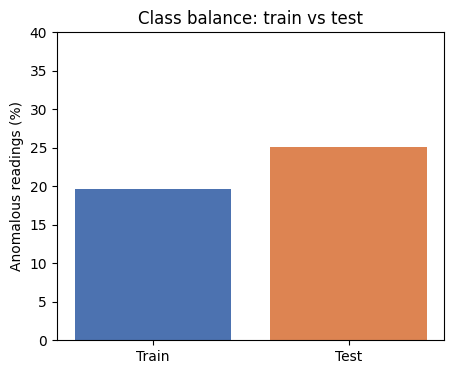

In [3]:
train_pct = 100 * y_train.mean()
test_pct  = 100 * y_test.mean()

print(f"Train anomaly rate: {train_pct:.1f}%  ({y_train.sum()} of {len(y_train)})")
print(f"Test  anomaly rate: {test_pct:.1f}%  ({y_test.sum()} of {len(y_test)})")

plt.figure(figsize=(5, 4))
plt.bar(["Train", "Test"], [train_pct, test_pct], color=["#4C72B0", "#DD8452"])
plt.ylabel("Anomalous readings (%)")
plt.title("Class balance: train vs test")
plt.ylim(0, 40)
plt.show()

## Check 2: Do features actually look different for anomalies?

If normal and anomalous readings have IDENTICAL distributions,
no model can tell them apart. We should see a visible difference,
especially in cpu_usage and its z_score.

Note: these values were already scaled by StandardScaler in
data_prep.py, so they will NOT look like raw percentages
(0-100). Instead expect roughly -3 to +3, centered near 0.

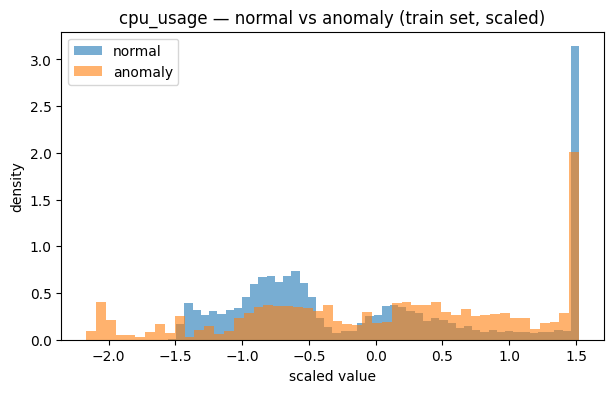

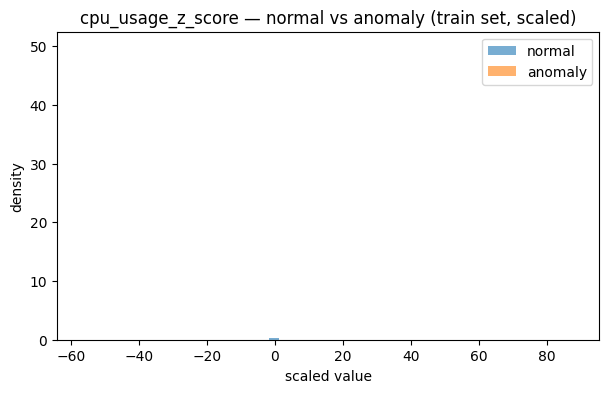

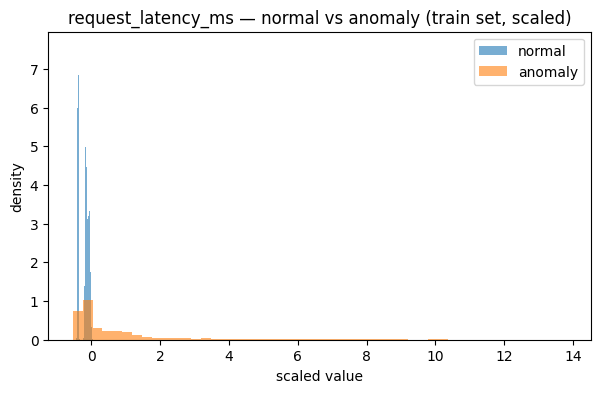

In [4]:
def plot_feature_by_class(feature_name: str, X: np.ndarray, y: np.ndarray, cols: list[str]):
    idx = cols.index(feature_name)
    values = X[:, idx]

    plt.figure(figsize=(7, 4))
    plt.hist(values[y == 0], bins=50, alpha=0.6, label="normal",   density=True)
    plt.hist(values[y == 1], bins=50, alpha=0.6, label="anomaly", density=True)
    plt.title(f"{feature_name} — normal vs anomaly (train set, scaled)")
    plt.xlabel("scaled value")
    plt.ylabel("density")
    plt.legend()
    plt.show()

plot_feature_by_class("cpu_usage", X_train, y_train, feature_cols)
plot_feature_by_class("cpu_usage_z_score", X_train, y_train, feature_cols)
plot_feature_by_class("request_latency_ms", X_train, y_train, feature_cols)

## Check 3: Are there any broken values?

NaN or infinity in the data will crash model training. This should
always print zero.

In [5]:
for name, arr in [("X_train", X_train), ("X_test", X_test),
                  ("X_train_seq", X_train_seq), ("X_test_seq", X_test_seq)]:
    n_nan = np.isnan(arr).sum()
    n_inf = np.isinf(arr).sum()
    status = "✅ clean" if (n_nan == 0 and n_inf == 0) else "❌ PROBLEM"
    print(f"{name:<14} NaN={n_nan:<6} Inf={n_inf:<6} {status}")

X_train        NaN=0      Inf=0      ✅ clean
X_test         NaN=0      Inf=0      ✅ clean
X_train_seq    NaN=0      Inf=0      ✅ clean
X_test_seq     NaN=0      Inf=0      ✅ clean


## Check 4: Did scaling actually work?

After StandardScaler, every column in X_train should have a mean
close to 0 and a standard deviation close to 1. X_test does NOT
need to match exactly (it wasn't used to fit the scaler) but should
be in a similar range.

In [6]:
means = X_train.mean(axis=0)
stds  = X_train.std(axis=0)

summary = pd.DataFrame({
    "feature": feature_cols,
    "train_mean": means.round(3),
    "train_std":  stds.round(3),
})
summary

,feature,train_mean,train_std
0,cpu_usage,0.0,1.0
1,cpu_usage_rolling_avg,0.0,1.0
2,cpu_usage_z_score,0.0,1.0
3,cpu_usage_rate_of_change,0.0,1.0
4,memory_usage,0.0,1.0
5,memory_usage_rolling_avg,-0.0,1.0
6,memory_usage_z_score,0.0,1.0
7,memory_usage_rate_of_change,-0.0,1.0
8,request_latency_ms,-0.0,1.0
9,request_latency_ms_rolling_avg,0.0,1.0


## Check 5: What does an anomaly actually look like over time?

Plot cpu_usage across a slice of readings, with anomalous points
marked in red. This is the closest thing to "does this look right
to a human eye".

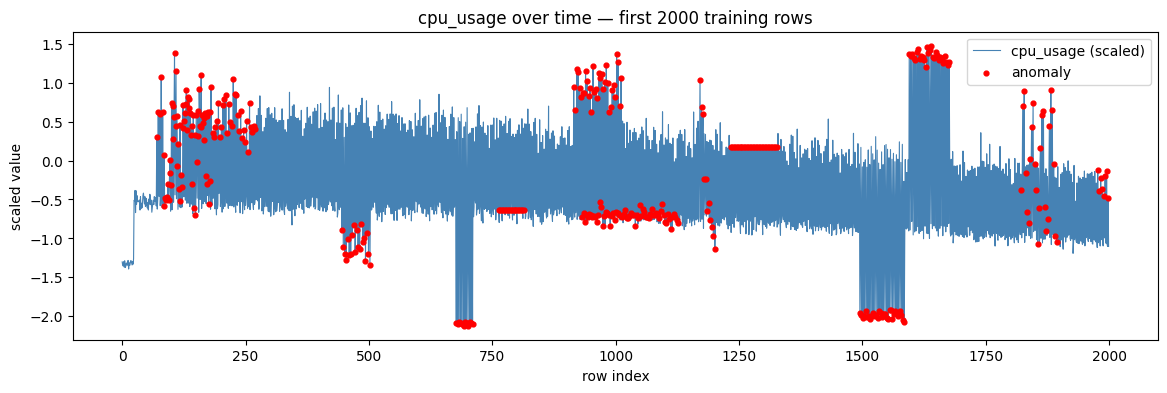

In [7]:
idx = feature_cols.index("cpu_usage")
window = slice(0, 2000)   # first 2000 rows — enough to see a few episodes

values = X_train[window, idx]
labels = y_train[window]

plt.figure(figsize=(14, 4))
plt.plot(values, color="steelblue", linewidth=0.8, label="cpu_usage (scaled)")
plt.scatter(np.where(labels == 1)[0], values[labels == 1],
           color="red", s=12, label="anomaly", zorder=5)
plt.title("cpu_usage over time — first 2000 training rows")
plt.xlabel("row index")
plt.ylabel("scaled value")
plt.legend()
plt.show()